In [ ]:
import pandas as pd
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
DIR = "Datasets For Testing/Advertising.csv"
df = pd.read_csv(DIR).drop("ID", axis=1)
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


<Axes: xlabel='newspaper', ylabel='sales'>

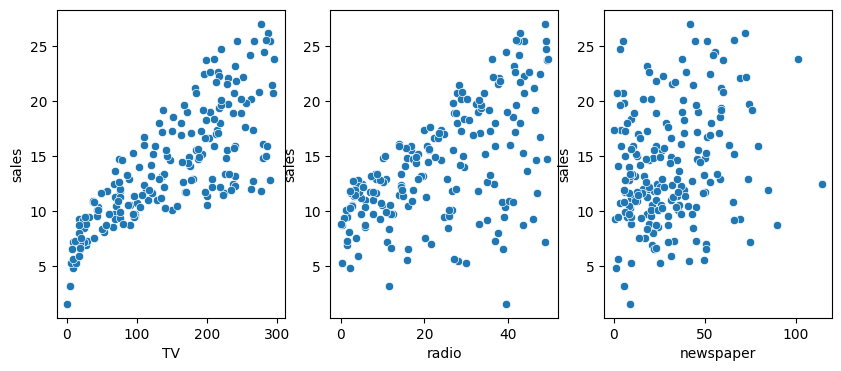

In [3]:
fig, axis = plt.subplots(1,3,figsize=(10,4))

sns.scatterplot(x=df["TV"], y= df["sales"],ax=axis[0])
sns.scatterplot(x=df["radio"], y= df["sales"], ax=axis[1])
sns.scatterplot(x=df["newspaper"], y= df["sales"], ax=axis[2])

In [4]:
X = df.drop("sales", axis=1)
y = df["sales"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
from simpleml.linear_models import LinearRegression
model = LinearRegression(optimizer="sgd", l2_ratio=0, random_seed=42)

In [6]:
model_reg = LinearRegression(optimizer="sgd", l2_ratio=0.0001, random_seed=42)

In [14]:
from simpleml.scaling import z_score_standardization
reg = model.fit(z_score_standardization(X_train, X_train), y_train)
reg_l2 = model.fit(z_score_standardization(X_train, X_train), y_train)

Val Loss: 3.9532041692943034
Val Loss: 3.953204169294303


In [ ]:
y_pred = reg.predict(X_test, scaling=False)
y_pred_l2 = reg_l2.predict(X_test)

In [22]:
from simpleml.metrics import regression_report
print("Without L2 Regularization: ", regression_report(y_test, y_pred))
print("With L2 Regularization: ", regression_report(y_test, y_pred_l2))

Without L2 Regularization:  {'R2 Score': -13527.1494, 'Mean Squared Error': 426997.0124, 'Mean Absolute Error': 563.5195, 'Root Mean Squared Error': 653.4501, 'Mean Absolute Percentage Error': 3838.552}
With L2 Regularization:  {'R2 Score': -13527.1494, 'Mean Squared Error': 426997.0124, 'Mean Absolute Error': 563.5195, 'Root Mean Squared Error': 653.4501, 'Mean Absolute Percentage Error': 3838.552}


In [11]:
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

model = make_pipeline(StandardScaler(), SGDRegressor(random_state=42))
regsk = model.fit(X_train, y_train)


In [10]:
y_pred = regsk.predict(X_test)
r2_score(y_test,y_pred)

-7.226969378743642e+24

In [86]:
regsk.predict([df.loc[0].drop("sales")])

C:\Users\Ahmed\anaconda3\envs\tf_cpu\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([20.5924376])

<Axes: xlabel='TV', ylabel='sales'>

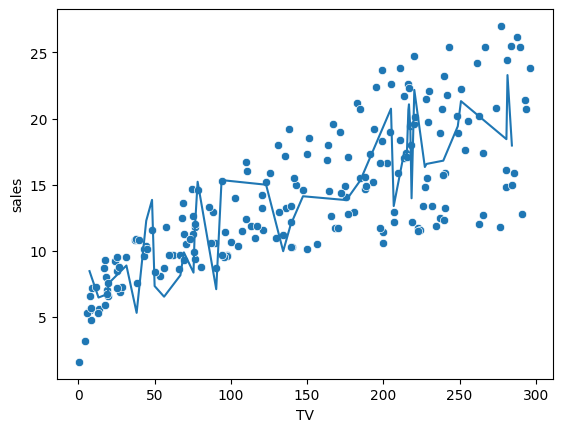

In [88]:
sns.scatterplot(x=df["TV"], y=df["sales"])
sns.lineplot(x=X_test["TV"], y=y_pred)

## Linear Regression implementation
### However there's still some to do things to improve apon it
### 1. Add adaptive varient possibly AdaGrad (Done)
### 2. Clean up the code (Done) 
### 3. Early stopping based on MSE (Done)
### 3. Implement Multiple Linear Regression (Done)
### 4. Regularization Techniques??
### 5. Splitting training code for each different optimizer for better code scalability (Done)
### 6. Implement Mini-Batch SGD (Done)
### 7. Implement lr scheduler (Done)

#### It seems I am reaching the limit with vanilla gradient descent with this few data points if I want a better model with similar layout I need more data points ALOT more & possibly some of the improvements above might help